## **Modelo preditivo de classificação de score de crédito**

### **Objetivo** 

#### classificar antecipadamente os clientes com scores de crédito: baixo, médio ou alto,

#### através de um modelo de machine learning capaz de cruzar as informações disponíveis dos indivíduos e avaliar os riscos de crédito,

#### auxiliando o time de negócios a trazer soluções aos clientes de acordo com sua classificação de risco.

### **Parte III**

#### - treinamento de modelos,
#### - torneio, escolha do modelo vencedor,
#### - tunning do modelo vencedor,
#### - Avaliação e performance final em dados novos.

## **Bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import(
    train_test_split,
    RandomizedSearchCV,
    cross_val_score,
    cross_val_predict,
    StratifiedKFold,
    learning_curve
)

from sklearn.metrics import(
    confusion_matrix,
    classification_report,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score,
    average_precision_score,
    roc_auc_score,   
)

In [2]:
# carregamento das bases de dados
X_train, X_test, y_train, y_test = joblib.load('../bases/bases_modelagem/dados_modelagem.pkl')

# checando estruturas
print(f'base de treino final: {X_train.shape[0]} linhas | {X_train.shape[1]} colunas')
print(f'base de teste final: {X_test.shape[0]} linhas | {X_test.shape[1]} colunas')

base de treino final: 131 linhas | 12 colunas
base de teste final: 33 linhas | 12 colunas


## **Treinamento do 1° modelo - Árvore de decisão (baseline)**

In [3]:
# instanciando o modelo 
baseline = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='gini')

# técnica do `stratifiedkfold` para desbalanceamento de classes
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

# treinamento com cross validation
scores = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring='average_precision'     # métrica mais robusta que roc_auc em dados desbalanceados
)

print(f'Resultados das sub amostras: \n {scores}')
print(f'média PR-AUC: \n {scores.mean():.2f}')
print(f'desvio padrão: \n {scores.std():.4f}')

Resultados das sub amostras: 
 [0.76851852 0.94668295 0.77661568 0.78027066 0.92985755]
média PR-AUC: 
 0.84
desvio padrão: 
 0.0802


#### o primeiro modelo já obteve uma ótima performance, embora tenha apresentado um pouco de instabilidade entre os folds de treinamento, variando de 0.77 a 0.95.
#### a média PR-AUC de 0.84, indica ótima capacidade de detectar a classe de score dos clientes, inclusive a classe minoritária.

### **treinamento final do baseline**

In [4]:
# treinando
baseline.fit(X_train, y_train)

# prevendo os dados de treino
y_prev = baseline.predict(X_train)
y_prob = baseline.predict_proba(X_train)

# métrica de ROC-AUC adaptada para 3 classes (usando estratégia One-vs-Rest)
roc_auc_multiclass = roc_auc_score(y_train, y_prob, multi_class='ovr')
pr_auc_multiclass = average_precision_score(y_train, y_prob, average='macro')

print(f'PR-AUC média da validação cruzada: {scores.mean():.2f}')
print(f'ROC-AUC do treino final: {roc_auc_multiclass:.4f}')
print(f'PRECISION-AUC do treino final : {pr_auc_multiclass:.4f}')
print(f'Relatório de classificação:')
print(classification_report(y_train, y_prev))

PR-AUC média da validação cruzada: 0.84
ROC-AUC do treino final: 0.9994
PRECISION-AUC do treino final : 0.9975
Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.97      1.00      0.98        29
           2       1.00      0.99      0.99        90

    accuracy                           0.99       131
   macro avg       0.99      1.00      0.99       131
weighted avg       0.99      0.99      0.99       131



#### A pr_auc de 0.99 consolida o baseline como tendo excelente capacidade preditora de score de crédito

#### A técnica `class_weight='balanced'` faz o modelo focar também em acertar a classe minoritária, mitigando os erros de falsos negativos e maximizando recall, cravando Acurácia de 0.99.

#### Nas próximas etapas será analisada a performance do modelo em generalizar para novos dados ou se esse excelente resultado é por conta de um sobreajuste do modelo aos dados.

## **treinamento do 2° modelo - Random Forest**

In [5]:
# instanciando o segundo modelo 
model = RandomForestClassifier(
    n_estimators=100,           # poucas árvores pois a base é pequena.
    max_depth=3,               # pouca profundidade para evitar overfitting.
    random_state=42,            # garante reprodutibilidade
    criterion='gini',           # pureza das folhas
    min_samples_leaf=5,         # exige mais amostras por folha, evitando criar regras super específicas.
    class_weight='balanced'     # faz o modelo detectar também a classe minoritária
)

# treinamento com validação cruzada
scores1 = cross_val_score(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring='average_precision'
)

print(f'Resultados das sub amostras: \n {scores1}')
print(f'média PR-AUC: \n {scores1.mean():.2f}')
print(f'desvio padrão: \n {scores1.std():.4f}')

Resultados das sub amostras: 
 [1.         0.96964887 0.96699268 0.94294069 0.93888889]
média PR-AUC: 
 0.96
desvio padrão: 
 0.0220


#### o Random forest apresentou melhor robustez e melhor métrica PR-AUC em cada fold, variando de 0.94 a 0.99.
#### a média PR-AUC de 0.96, alta de 14% em comparação ao baseline, indica alta eficiência em detectar a classe de score dos clientes, inclusive a classe minoritária.

In [6]:
# treinando
model.fit(X_train, y_train)

# prevendo os dados de treino
y_prev1 = model.predict(X_train)
y_prob1 = model.predict_proba(X_train)

# métrica de ROC-AUC adaptada para 3 classes (usando estratégia One-vs-Rest)
roc_auc_multiclass1 = roc_auc_score(y_train, y_prob1, multi_class='ovr')
pr_auc_multiclass1 = average_precision_score(y_train, y_prob1, average='macro')

print(f'PR-AUC média da validação cruzada: {scores1.mean():.2f}')
print(f'ROC-AUC do treino final: {roc_auc_multiclass1:.2f}')
print(f'PRECISION-AUC do treino final : {pr_auc_multiclass1:.2f}')
print(f'Relatório de classificação:')
print(classification_report(y_train, y_prev1))

PR-AUC média da validação cruzada: 0.96
ROC-AUC do treino final: 0.99
PRECISION-AUC do treino final : 0.98
Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.90      0.97      0.93        29
           2       0.99      0.97      0.98        90

    accuracy                           0.97       131
   macro avg       0.96      0.98      0.97       131
weighted avg       0.97      0.97      0.97       131



#### A pr_auc de 0.99 mantida pelo random forest, indica robustez do modelo e é esperado que ele continue com essa performance em novos dados.

#### A pequena queda nas métricas recall, de 1.00 para 0.97 e precision da classe 1, de 0.97 para 0.90 é saudável e mostra que o modelo não decorou as amostras e possui sim capacidade de generalização.

## **Avaliação dos modelos**

,modelo,PR_AUC,ROC_AUC,Acuracia
0,Árvore de decisão,1.00,1.00,0.99
1,Random Forest,0.98,0.99,0.97


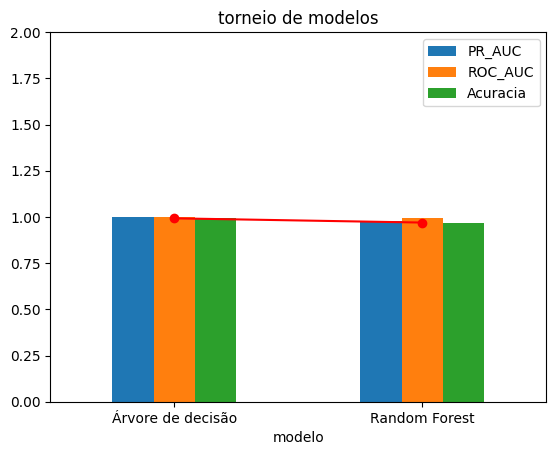

In [13]:
# transformando relatório de classificação em dicionário
relatorio_arvore = classification_report(y_train, y_prev, output_dict=True)
relatorio_rf = classification_report(y_train, y_prev1, output_dict=True)

# transformando dicionário em dataframe
rel_arvore = pd.DataFrame(relatorio_arvore)
rel_rf = pd.DataFrame(relatorio_rf)

# dicionario do torneio de modelos
torneio = {
    'modelo': ['Árvore de decisão', 'Random Forest'],
    'PR_AUC': [pr_auc_multiclass, pr_auc_multiclass1],
    'ROC_AUC': [roc_auc_multiclass, roc_auc_multiclass1],
    'Acuracia': [rel_arvore.loc['precision','accuracy'], rel_rf.loc['precision','accuracy']]
}

torneio = pd.DataFrame(torneio)

display(torneio.round(2))

# visual
ax = torneio.plot(kind='bar', x='modelo')
plt.title('torneio de modelos')
plt.xticks(rotation=0)
plt.ylim(0,2)

ax.plot(
    torneio['Acuracia'], 
    color='red', 
    marker='o', 
)


plt.show()

#### O random forest é o escolhido para dar sequência ao projeto, pois é um modelo mais robusto, com uma gama maior de técnica para uma maior eficiência.

## **Tunning do modelo**
### **Ajuste de hiperparâmetros**

In [ ]:
# instanciando o modelo 
model_rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# dicionario de parâmetros
param = {
    'n_estimators': randint(20, 100),
    'max_depth': randint(2, 4),
    'criterion': ['gini', 'entropy'],
    'min_samples_split': randint(3, 7),
    'min_samples_leaf': randint(3, 7)
}

# busca
search = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param,
    cv=cv,
    n_iter=20,
    n_jobs=-1,
    scoring='roc_auc_ovr',       # métrica para problemas multiclasses
    random_state=42
)

# treinamento
search.fit(X_train, y_train)

print(f'Métrica Roc_Auc encontrada: {search.best_score_:.2}')
print('Melhores parâmetros encontrados')
print(search.best_params_)

Métrica Roc_Auc encontrada: 0.99
Melhores parâmetros encontrados
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 25}


#### Parâmetros escolhidos pelo modelo:

- `n_estimators': 25`: floresta com 25 árvores de decisão é compreensível pela base não ser grande.

- `criterion: 'entropy'`: faz com que o Random Forest utilize a entropia de Shannon para medir a pureza e orientar as divisões das árvores de decisão.

- `max_depth: 3`: evita overfitting e controla a profundidade das árvores para que o modelo não decore os dados.

- `min_samples_leaf: 4`: define que qualquer nó folha deve conter pelo menos 4 amostras para o modelo não decorar regras tão específicas.

- `min_samples_split': 4`: exige que um nó tenha pelo menos 4 amostras para que ele possa ser dividido em nós menores.

In [ ]:
# modelo final tunnado
best_model = search.best_estimator_

# treinamento final
best_model.fit(X_train, y_train)

# previsões do treino
y_prev_treino = best_model.predict(X_train)
y_prob_treino = best_model.predict_proba(X_train)


# gerando relatório da performance no treino
print('ROC_AUC:')
print(roc_auc_score(y_train, y_prob_treino, multi_class='ovr'))
print('PR_AUC:')
print(average_precision_score(y_train, y_prob_treino, average='macro'))
print('Relatório de Classificação:')
print(classification_report(y_train, y_prev_treino))

ROC_AUC:
0.9913174689556227
PR_AUC:
0.9728341270099485
Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.90      0.97      0.93        29
           2       0.99      0.97      0.98        90

    accuracy                           0.97       131
   macro avg       0.96      0.98      0.97       131
weighted avg       0.97      0.97      0.97       131



#### o modelo tunnado manteve a alta performance, sem sinais de overfitting.

#### e com variáveis bastante informativas capazes de explicar a variabilidade dos scores de crédito, com:

- `Acurácia`: 0.97. 

## **Teste final**

In [ ]:
# previsões na base de teste
y_prev_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)

# gerando relatório da performance no teste 
print('ROC_AUC:')
print(roc_auc_score(y_test, y_prob_test, multi_class='ovr'))
print('PR_AUC:')
print(average_precision_score(y_test, y_prob_test, average='macro'))
print('Relatório de Classificação:')
print(classification_report(y_test, y_prev_test))

ROC_AUC:
0.9795508838987099
PR_AUC:
0.9668048779917534
Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.86      0.86      0.86         7
           2       0.96      0.96      0.96        23

    accuracy                           0.94        33
   macro avg       0.94      0.94      0.94        33
weighted avg       0.94      0.94      0.94        33



#### **Avaliação do teste final:**

- `ROC_AUC: 0.98`: mostra a robustez do modelo em diferenciar as classes: baixo, médio e alto score.

- `PR_AUC: 0.97`: indica que de 100 clientes, o modelo consegue acertar a score de crédito de 97 clientes.

- `Acurácia: 0.94`: representando a taxa geral de acerto do modelo.

## **Análise da curva de aprendizado**

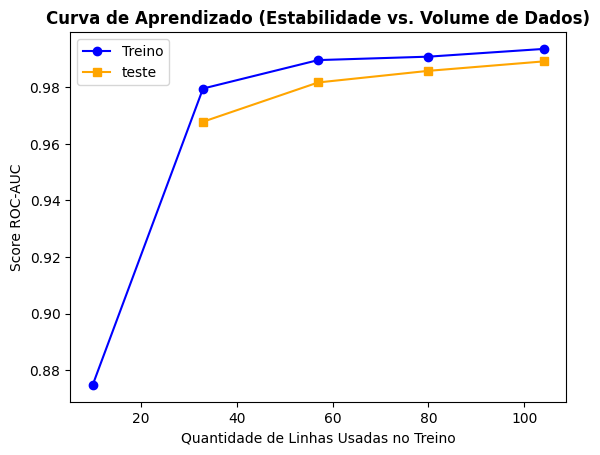

In [ ]:
# Configurando a curva usando o modelo final
train_sizes, train_scores, test_scores = learning_curve(
    estimator= best_model, # Random Forest tunado
    X=X_train, y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5, 7),    # Testa com 10%, 30%, 50%... da base
    cv=cv, scoring='roc_auc_ovr', n_jobs=-1
)

# 2. Calcula as médias das notas
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 3. Plota o gráfico profissional
plt.plot(train_sizes, train_mean, label='Treino', marker='o', color='blue')
plt.plot(train_sizes, test_mean, label='teste', marker='s', color='orange')
plt.title('Curva de Aprendizado (Estabilidade vs. Volume de Dados)', fontsize=12, fontweight='bold')
plt.xlabel('Quantidade de Linhas Usadas no Treino')
plt.ylabel('Score ROC-AUC')
plt.legend()
plt.show()

#### linhas próximas e métricas altas indica saúde do modelo e a tendência de estabilidade em 0.98 mostra que não há necessidade de novos dados para melhoria do modelo.

## **Análise da matriz de confusão**

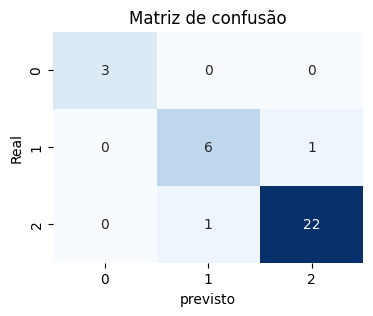

In [ ]:
# gerando matriz de confusão
cm = confusion_matrix(y_test, y_prev_test)

# visual
plt.figure(figsize=(4,3))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title('Matriz de confusão')
plt.xlabel('previsto')
plt.ylabel('Real')

plt.show()

- `classe 0`: o modelo acertou todas as previsões.

- `classe 1`: das 7 amostras de score médio, o modelo classificou uma amostra como score alto.

- `classe 2`: das 23 amostras de score alto, o modelo classificou uma amostra como score médio.

## **Análise das features Importance**

,variaveis,importancia
4,propriedade,0.260909
11,faixa_renda,0.177313
0,idade,0.141454
1,genero,0.108840
10,casado_casa_propria,0.089144


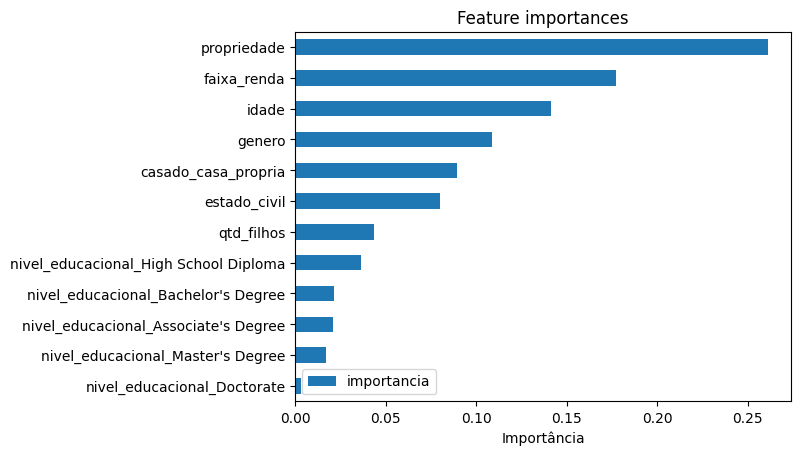

In [ ]:
# gerando importancia
importancia = best_model.feature_importances_

# gerando tabela
feature_importances = {
    'variaveis': X_train.columns,
    'importancia': importancia
}

tb_modelo = pd.DataFrame(feature_importances)
display(tb_modelo.sort_values(by='importancia', ascending=False).head())

# visual
tb_modelo.sort_values(by='importancia', ascending=False).plot(
    kind='barh',
    x='variaveis',
    y='importancia'
)

plt.title('Feature Importances')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.gca().invert_yaxis()

plt.title("Feature importances")
plt.ylabel('')

#plt.savefig('../imagens/f_importances.png')
plt.show()

## **conclusões**

#### o modelo apresentou excelente capacidade de generalização, com `~96% de PR-AUC`, onde o modelo é capaz de prever o score corretamente de 96 a cada 100 clientes e acerto geral de `94% de acurácia.`

#### Interpretando as decisões do modelo de machine learning, nota-se que ele cruza dados socioeconomicos:

- propriedade

- faixa de renda

#### e dados demográficos:

- idade

- gênero

- estado civil

#### nas suas decisões, deixando de ser apenas uma ferramenta técnica e passando a ser um motor de crescimento sustentável, pois equilibra a expansão da base de clientes com o controle rigoroso do risco de crédito.

#### o modelo entrega solução em:

- ***mitigação de Riscos:*** reduzindo a inadimplência ao barrar perfis de alto risco antes da concessão do crédito.

- ***automação de Decisões:*** substituindo a análise manual lenta por aprovações instantâneas e escaláveis.

- ***personalização comercial:*** permitindo oferecer juros menores para bons pagadores e limites adequados ao risco de cada cliente.

- ***vantagem competitiva:*** identificando padrões sutis de comportamento que os modelos tradicionais dos bancos não conseguem enxergar.

#### gerando valor em:

- ***bancos e Fintechs:*** definindo o limite do cartão de crédito e a taxa de juros de um empréstimo em segundos.

- ***varejo e e-commerce:*** liberando a opção de "crediário próprio" ou boleto parcelado com segurança para o consumidor.

- ***empresas de telecom / energia:*** avalia o risco de o cliente atrasar a conta mensal antes de aprovar a instalação do serviço.

- ***imobiliárias:*** agiliza a análise de ficha de novos inquilinos para contratos de aluguel.